# QAOA Example (MaxCut)

这里展示如何使用 `cqlib-algorithm` 中的 QAOA 求解 MaxCut 问题。

In [3]:
from cqlib_algorithm.problems.maxcut import MaxCut
from cqlib_algorithm.mappings.convert import maxcut_to_qubo, qubo_to_ising
from cqlib_algorithm.visualization.maxcut_plot import plot_maxcut
from cqlib_algorithm.execution import LocalRunner
from cqlib_algorithm.algorithms.qaoa import QAOASolver, QAOAConfig
from cqlib_algorithm.optimizers.options import OptimizerOptions
print('Imports ready')

Imports ready


## 1. 定义 MaxCut 实例

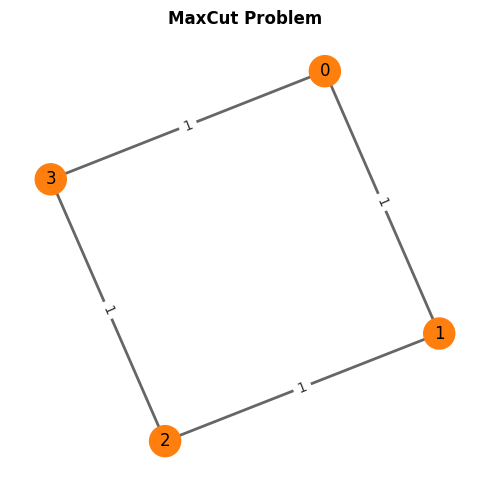

In [4]:
weights =  {(0,1):1, (1,2):1, (2,3):1, (3,0):1}
mc = MaxCut(n=4, weights=weights)
plot_maxcut(n=mc.n, weights=mc.weights, partition={}, title='MaxCut Problem')

## 2. Maxcut → QUBO

In [7]:
qubo  = maxcut_to_qubo(mc)
print(qubo)

========== [ QUBO ] ==========
Maximize: - 2*x_0*x_1 - 2*x_0*x_3 - 2*x_1*x_2 - 2*x_2*x_3 + 2*x_0 + 2*x_1 + 2*x_2 + 2*x_3



## 3. QUBO → Ising

In [8]:
ising = qubo_to_ising(qubo)
print(ising)

========== [ Ising Hamiltonian ] ==========
Paulis = ['IIZZ', 'ZIIZ', 'IZZI', 'ZZII'],
coeffs = [0.500, 0.500, 0.500, 0.500]
offset = -2.000



## 4. 运行 QAOA（LocalRunner）

[iter=  1] f=0.678 theta=[0.800, 0.850, 0.800, 0.200, 0.200, 0.200]
[iter=  2] f=0.268 theta=[0.825, 0.825, 0.825, 0.100, 0.225, 0.225]
[iter=  3] f=0.268 theta=[0.825, 0.825, 0.825, 0.100, 0.225, 0.225]
[iter=  4] f=0.268 theta=[0.825, 0.825, 0.825, 0.100, 0.225, 0.225]
[iter=  5] f=0.268 theta=[0.825, 0.825, 0.825, 0.100, 0.225, 0.225]
[iter=  6] f=-0.056 theta=[0.889, 0.889, 0.764, 0.081, 0.185, 0.211]
[iter=  7] f=-0.056 theta=[0.889, 0.889, 0.764, 0.081, 0.185, 0.211]
[iter=  8] f=-0.648 theta=[0.919, 0.853, 0.861, -0.037, 0.170, 0.222]
[iter=  9] f=-0.648 theta=[0.919, 0.853, 0.861, -0.037, 0.170, 0.222]
[iter= 10] f=-0.648 theta=[0.919, 0.853, 0.861, -0.037, 0.170, 0.222]
[iter= 11] f=-0.942 theta=[0.926, 0.926, 0.771, -0.176, 0.197, 0.268]
[iter= 12] f=-0.942 theta=[0.926, 0.926, 0.771, -0.176, 0.197, 0.268]
[iter= 13] f=-0.948 theta=[0.998, 0.910, 0.780, -0.171, 0.183, 0.266]
[iter= 14] f=-0.948 theta=[0.998, 0.910, 0.780, -0.171, 0.183, 0.266]
[iter= 15] f=-0.948 theta=[0.998

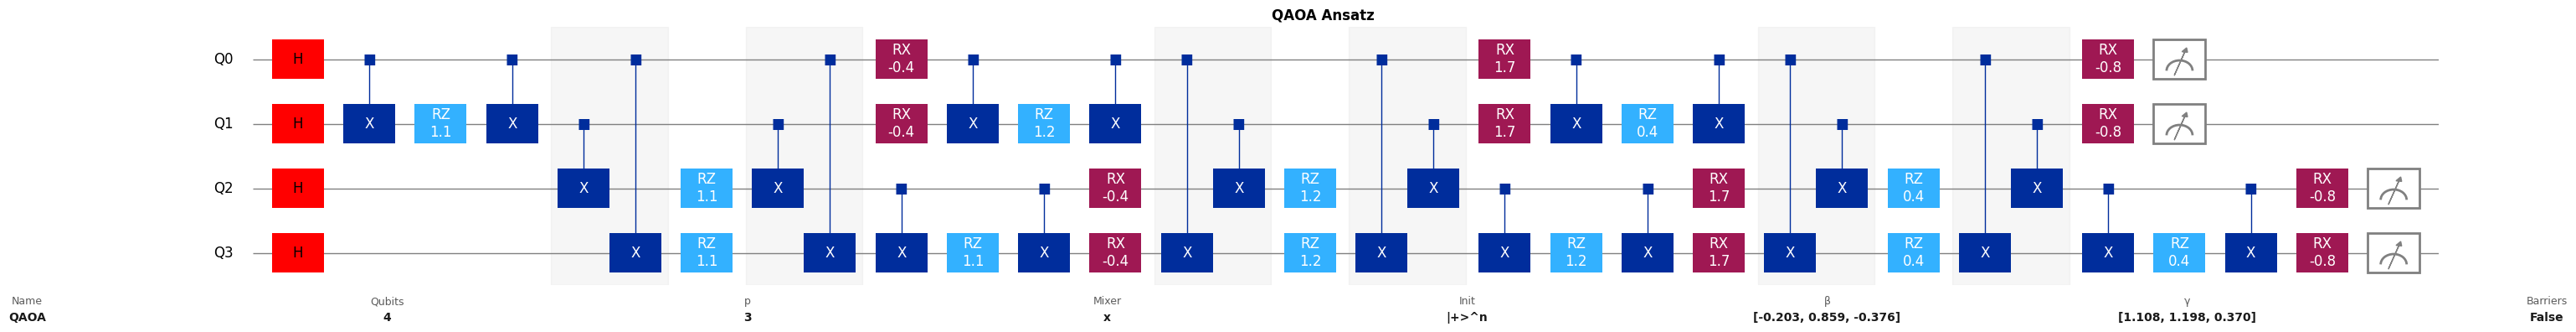

In [23]:
opt_cfg = OptimizerOptions(name="nelder-mead", options={"maxiter": 100})
solver = QAOASolver(ising, 
                    runner=LocalRunner(), 
                    qaoa_cfg=QAOAConfig(reps=3, mixer="x"), 
                    opt_cfg=opt_cfg)
res = solver.run()

## 5. 可视化：运行结果

In [16]:
res.print_result()


========== [ Experiment Information ] ==========
任务ID     : 20251023092513
shots 数量 : 1000

========== [ Optimize Configs ] ==========
runner      : LocalRunner
qaoa_cfg    : {'reps': 3, 'mixer': 'x', 'shots': 1000, 'name': 'QAOA', 'wrap_angles': True, 'need_transpile': None, 'verbose': True}
opt_cfg    : {'name': 'nelder-mead', 'options': {'maxiter': 100}}

========== [ Measurement Results ] ==========
probability : {'1010': 0.507, '0101': 0.473, '0010': 0.004, '1000': 0.004, '1011': 0.004, '0111': 0.003, '1101': 0.002, '0001': 0.001, '0100': 0.001, '1100': 0.001}


## 6. 可视化：迭代曲线与概率分布

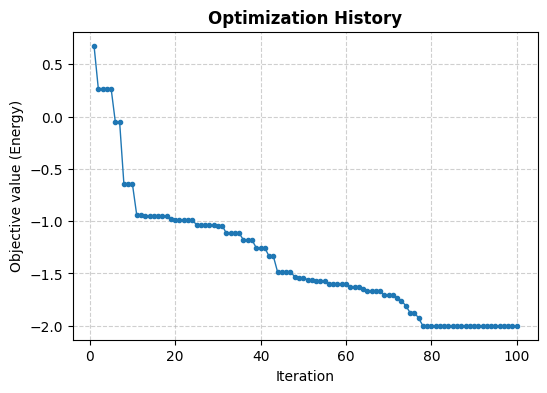

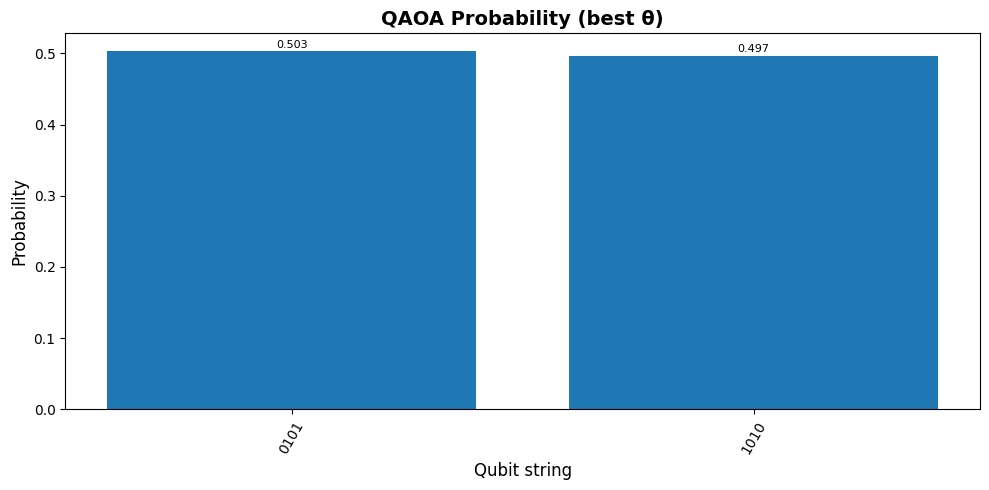

In [24]:
res.plot_history(title="Optimization History")
res.plot_probability(title="QAOA Probability (best θ)", topk=20)

## 7. 可视化：最优 MaxCut 解


========== [ Optimization Results ] ==========
Best gammas : [1.108, 1.198, 0.370]
Best betas  : [-0.203, 0.859, -0.376]
Best energy : -2.000
Best Qubit string:  0101
Best solution: [1, 3]
Max-Cut value: 4.000


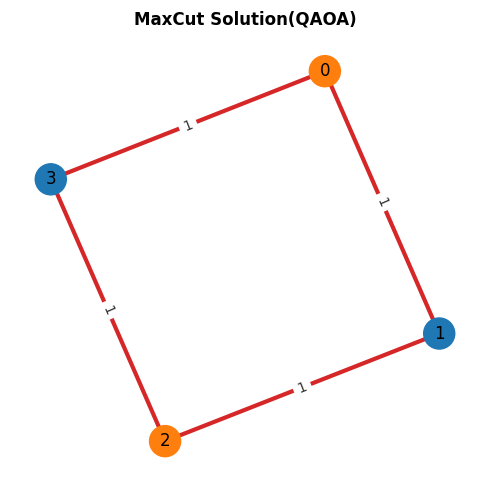

[1, 3]

In [25]:
res.plot_maxcut_solution(n=mc.n, weights=mc.weights, title="MaxCut Solution(QAOA)")

### 可选：对接中电信“天衍”量子计算云平台后端
将 `LocalRunner()` 替换为 `TianYanRunner()`：
```python
from cqlib_algorithm.execution import TianYanRunner
runner = TianYanRunner(login_key='YOUR_KEY', machine='tianyan_sw')
```
